# SDP hierarchy per la discriminazione di 2 stati

**Rilassamento SDP** del problema di **state discrimination a 2 stati**.

Scenario (Prep. & Meas.):
- Alice prepara $\rho_0$ oppure $\rho_1$;
- Bob fa una misura binaria con POVM associata ${M}_{b=0,1}$;
- il vincolo fisico è sul peso del vacuum state:

$$\langle 0|\rho_x|0\rangle=\operatorname{Tr}(\rho_x\sigma_0)\ge 1-\omega_x,\qquad\omega_1=\omega_2=\omega$$

con $\sigma_0=|0\rangle\langle0|$ proiettore nello stato di Fock $|0\rangle$.

La probabilità media di successo è
$$W_{2\mathrm{disc}}=\frac12p(0|0)+\frac12p(1|1)=\frac12\left[\operatorname{Tr}(\rho_0M_0)+\operatorname{Tr}(\rho_1M_1)\right]$$

Analiticamente si trova che il valore ottimale è

$$W^Q_{2\mathrm{disc}}=\frac12+\sqrt{\omega(1-\omega)}$$


## 1. Import

In [1]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

## 2. Moment matrix

Invece di cercare direttamente matrici per $\rho_0,\rho_1,M_0,M_1,\sigma_0$, introduciamo una **moment matrix** $\Gamma$.

Introduciamo un insieme $\mathbb{O}$ di liste di operatori che servono a caratterizzare il problema. 


Le righe e colonne della matrice $\Gamma$ sono indicizzate da **parole non commutative negli operatori**, di lungehzza $k$, per esempio fermandosi al primo livello ($k=1$):

$$\mathbb{S_1} = \left\{I,\quad \rho_0,\quad \rho_1, \quad M_0,\quad M_1, \quad \sigma_0\right\}$$

Gli elementi sono

$$\Gamma_{u,v}=\operatorname{Tr}(u^\dagger v) \quad \forall u,v \in \mathbb{S_1}$$

Se gli operatori esistono davvero, allora necessariamente, per costruzione

$$\Gamma\succeq0.$$

Quindi l'SDP cerca valori compatibili per i momenti e tutto il problema (funzione obiettivo + constraints) è linearizzato su di essi.


## 3. Parole non commutative in Python

Una singola parola può essere rappresentata, per comodità, come una tupla di stringhe i.e

```python
("r0", "M0")
```

significa $\rho_0M_0$.

La tupla vuota `()` rappresenta l'identità $I$.

Uso:
- `"r0"` per $\rho_0$;
- `"r1"` per $\rho_1$;
- `"M_0"` per la POVM associata al primo outcome (1 al secondo);
- `"S"` per $\sigma_0$.


In [2]:
# M e S sono proiettori: M^2=M, S^2=S.
# rho_0 e rho_1 sono, in generale, stati misti.
projs = {"M0", "M1", "S"}

## 4. Riduzione delle parole

Si possono sempre apportare semplificazioni nelle parole, dovute ad esempio in questo caso alle relazioni dei proiettori:

$$M_mM_n=\delta_{mn}M_m,\qquad S_mS_n=\delta_{mn}S_m$$


In [ ]:
def reduce_word(w):
    """Riduce una parola usando idempotenza dei proiettori: M_b^2=M_b, S^2=S."""
    w = list(w)
    changed = True
    while changed:
        changed = False
        out = []
        i = 0
        while i < len(w):
            if i + 1 < len(w) and w[i] == w[i + 1] and w[i] in projs:
                out.append(w[i])
                i += 2
                changed = True
            else:
                out.append(w[i])
                i += 1
        w = out
    return tuple(w)


def is_zero_word(w):
    """
    Riconosce prodotti nulli per ortogonalità della misura: M0 M1 = M1 M0 = 0.
    """
    for a, b in zip(w, w[1:]):
        if a.startswith("M") and b.startswith("M") and a != b:
            return True
    return False

# Esempio
print(reduce_word(("M0", "M1", "r0", "S", "S")))
print(is_zero_word(("M0", "M1")))


('M0', 'M1', 'r0', 'S')
True


## 5. Ciclicità della traccia

La traccia soddisfa

$$\operatorname{Tr}(ABC)=\operatorname{Tr}(BCA)=\operatorname{Tr}(CAB).$$

Quindi parole che differiscono per rotazioni cicliche rappresentano lo stesso momento.

Useremo una forma canonica per non creare variabili duplicate.

Inoltre, identifichiamo anche una parola con la parola invertita, coerente con operatori hermitiani e momenti reali.


In [ ]:
def rotations(w):
    """Restituisce tutte le rotazioni cicliche della parola w"""
    if len(w) == 0:
        return [()]
    return [w[i:] + w[:i] for i in range(len(w))]

def canonical_trace_word(w):
    """Forma canonica di una parola dentro una traccia.
    Usa ciclicità della traccia e inversione, assumendo operatori hermitiani.
    """
    w = reduce_word(tuple(w))
    candidates = rotations(w) + rotations(tuple(reversed(w)))
    candidates = [reduce_word(c) for c in candidates]
    return min(candidates)

# Esempio
for word in [("r0", "M0", "S"), ("M0", "S", "r0"), ("S", "r0", "M0")]:
    print(word, "->", canonical_trace_word(word))


('r0', 'M0', 'S') -> ('M0', 'S', 'r0')
('M0', 'S', 'r0') -> ('M0', 'S', 'r0')
('S', 'r0', 'M0') -> ('M0', 'S', 'r0')


## 6. Costruzione della classe `TracialSDP`

La funzione importante è `T(w)`, che rappresenta formalmente l'operazione simbolica di traccia.

```python
T(("r0", "M0"))
```
sarà $\operatorname{Tr}(\rho_0M_0)$.

Dunque se una parola non è ancora stata vista, creiamo una nuova variabile scalare CVXPY con connotazione `T_w`



In [ ]:
class TracialSDP:
    def __init__(self):
        self.vars = {}

    def T(self, w):
        """Restituisce la variabile CVXPY associata a Tr(w), oppure 0 se la parola è nulla (per ortogonalità)."""
        w = tuple(w)
        if is_zero_word(w):
            return 0
        
        key = canonical_trace_word(tuple(w))
        if is_zero_word(key):
            return 0
        
        if key not in self.vars:
            name = "T_I" if len(key) == 0 else "T_" + "".join(key)
            self.vars[key] = cp.Variable(name=name)
        return self.vars[key]

    def moment_matrix(self, words):
        """Costruisce Gamma con Gamma[u,v] = Tr(u^dagger v)."""
        n = len(words)
        G = [[None for _ in range(n)] for _ in range(n)]
        for i, u in enumerate(words):
            for j, v in enumerate(words):
                u_dagger = tuple(reversed(u))
                G[i][j] = self.T(u_dagger + tuple(v))
        return cp.bmat(G)

    def localizing_matrix(self, words, rho):
        """
        Costruisce la localizing matrix associata a rho - rho^2 >= 0.
        Elemento [u,v] = Tr(u^dagger (rho-rho^2) v).
        """
        n = len(words)
        L = [[None for _ in range(n)] for _ in range(n)]
        for i, u in enumerate(words):
            for j, v in enumerate(words):
                left = tuple(reversed(u))
                right = tuple(v)
                L[i][j] = self.T(left + (rho,) + right) - self.T(left + (rho, rho) + right)
        return cp.bmat(L)


## 7. Una piccola moment matrix esplicita

Costruiamo una moment matrix indicizzata da

$$\{I,\rho_0,M_0,S\}.$$


In [6]:
def word_to_str(w):
    return "I" if len(w) == 0 else " ".join(w)

small_words = [(), ("r0",), ("M0",), ("S",)]
small_sdp = TracialSDP()
small_G = small_sdp.moment_matrix(small_words)

print("Parole di riga/colonna:")
for i, w in enumerate(small_words):
    print(i, word_to_str(w))

print("Variabili create:")
for key in sorted(small_sdp.vars.keys()):
    var = small_sdp.vars[key]
    print(f"{key}  -->  {var.name()}")


Parole di riga/colonna:
0 I
1 r0
2 M0
3 S
Variabili create:
()  -->  T_I
('M0',)  -->  T_M0
('M0', 'S')  -->  T_M0S
('M0', 'r0')  -->  T_M0r0
('S',)  -->  T_S
('S', 'r0')  -->  T_Sr0
('r0',)  -->  T_r0
('r0', 'r0')  -->  T_r0r0


## 8. SDP completa per 2-state discrimination

Vincoli:

1. moment matrix positiva:

$$\Gamma\succeq0$$

2. localizing matrices positive:

$$\Upsilon_x\succeq0$$

con

$$\Upsilon_x[u,v]=\operatorname{Tr}\left[u^\dagger(\rho_x-\rho_x^2)v\right]$$

3. normalizzazione degli stati:

$$\operatorname{Tr}(\rho_0)=\operatorname{Tr}(\rho_1)=1$$

4. normalizzazione del proiettore sul vuoto:

$$\operatorname{Tr}(S)=1$$

5. vincoli photon-number:

$$\operatorname{Tr}(\rho_xS)\ge1-\omega$$

6. completezza POVM:
$$M_0+M_1=I$$

Probabilità di successo (witness):

$$\mathcal{W}=\frac12p(0|\rho_0)+\frac12p(1|\rho_1)=\frac12\operatorname{Tr}(\rho_0M_0)+\frac12\operatorname{Tr}(\rho_1M_1)$$

Obiettivo:

$$\max_\Gamma\left[\frac12\left(\Gamma_{\rho_0,M_0}+\frac12\Gamma_{\rho_1,M_1}\right)\right]$$


In [ ]:
def build_words(include_extra=False):
    """
    Costruisce le parole necessarie per il rilassamento SDP.
    include_extra=False è il default per un confronto più pulito.
    Se True, aggiunge alcune parole di lunghezza 3 (ispirate a task più complessi).
    """
    rhos = ["r0", "r1"]
    measurements = ["M0", "M1"]

    words = [()]
    words += [(r,) for r in rhos]
    words += [(M,) for M in measurements]
    words += [("S",)]

    words += [(r, M) for r in rhos for M in measurements]
    words += [(r, "S") for r in rhos]
    words += [("S", M) for M in measurements]
    words += [(r, r) for r in rhos]
    words += [("S", r) for r in rhos]

    if include_extra:
        words += [(r, M, "S") for r in rhos for M in measurements]
        words += [(M, r, "S") for M in measurements for r in rhos]

    unique = []
    seen = set()
    for w in words:
        w = reduce_word(tuple(w))
        if is_zero_word(w):
            continue
        if w not in seen:
            seen.add(w)
            unique.append(w)
    return unique


def build_localizing_words():
    return [(), ("r0",), ("r1",), ("M0",), ("M1",), ("S",)]


def solve_two_state_discrimination(
    omega,
    solver="CLARABEL",
    verbose=False,
    include_extra_words=False,
):
    """
    Risolve il rilassamento SDP per discriminazione di 2 stati con POVM completa.
    Parametri:
    - omega: Vincolo Tr(rho_x S) >= 1 - omega.
    - include_extra_words: Se True aggiunge parole più forti di lunghezza 3.
    """
    sdp = TracialSDP()

    rhos = ["r0", "r1"]
    measurements = ["M0", "M1"]
    words = build_words(include_extra=include_extra_words)
    loc_words = build_localizing_words()

    Gamma = sdp.moment_matrix(words)
    constraints = [Gamma >> 0]

    for r in rhos:
        constraints.append(sdp.localizing_matrix(loc_words, r) >> 0)

    # Normalizzazione degli stati
    for r in rhos:
        constraints.append(sdp.T((r,)) == 1)

    # Normalizzazione del proiettore del vuoto S=sigma_0
    constraints.append(sdp.T(("S",)) == 1)

    # Vincolo sul peso del vuoto
    for r in rhos:
        constraints.append(sdp.T((r, "S")) >= 1 - omega)
        constraints.append(sdp.T((r, "S")) <= 1)

    # Completezza POVM: M0 + M1 = I
    for u in loc_words:
        for v in loc_words:
            lhs = sum(
                sdp.T(tuple(reversed(u)) + (M,) + tuple(v))
                for M in measurements
            )
            rhs = sdp.T(tuple(reversed(u)) + tuple(v))
            constraints.append(lhs == rhs)

    # Witness con POVM a due outcome
    W = 0.5 * (sdp.T(("r0", "M0")) + sdp.T(("r1", "M1")))

    problem = cp.Problem(cp.Maximize(W), constraints)
    problem.solve(solver=solver, verbose=verbose)

    analytic = 0.5 + np.sqrt(omega * (1 - omega))

    return {
        "omega": omega,
        "sdp_upper_bound": problem.value,
        "analytic": analytic,
        "absolute_error": None if problem.value is None else abs(problem.value - analytic),
        "status": problem.status,
        "num_moment_variables": len(sdp.vars),
        "num_words": len(words),
        "words": words,
        "localizing_words": loc_words,
        "moment_variables": sdp.vars,
    }


## 9. Test numerico

Per vari valori di $\omega$ confrontiamo il valore SDP con il valore analitico:

$$\frac12+\sqrt{\omega(1-\omega)}.$$

Tenendo in considerazione che il valore SDP è un upper bound.


In [8]:
omegas = [0.01, 0.05, 0.10, 0.25, 0.50]
results = []

for omega in omegas:
    res = solve_two_state_discrimination(omega, solver="MOSEK", include_extra_words=False)
    results.append(res)

for res in results:
    print(
        f"omega={res['omega']:.3f} | "
        f"SDP={res['sdp_upper_bound']:.10f} | "
        f"analytic={res['analytic']:.10f} | "
        f"err={res['absolute_error']:.2e} | "
        f"status={res['status']}"
    )

omega=0.010 | SDP=0.5994987090 | analytic=0.5994987437 | err=3.47e-08 | status=optimal
omega=0.050 | SDP=0.7179449200 | analytic=0.7179449472 | err=2.72e-08 | status=optimal
omega=0.100 | SDP=0.7999999219 | analytic=0.8000000000 | err=7.81e-08 | status=optimal
omega=0.250 | SDP=0.9330126836 | analytic=0.9330127019 | err=1.83e-08 | status=optimal
omega=0.500 | SDP=0.9999999830 | analytic=1.0000000000 | err=1.70e-08 | status=optimal


/tmp/ipykernel_10328/194247069.py:97: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=solver, verbose=verbose)


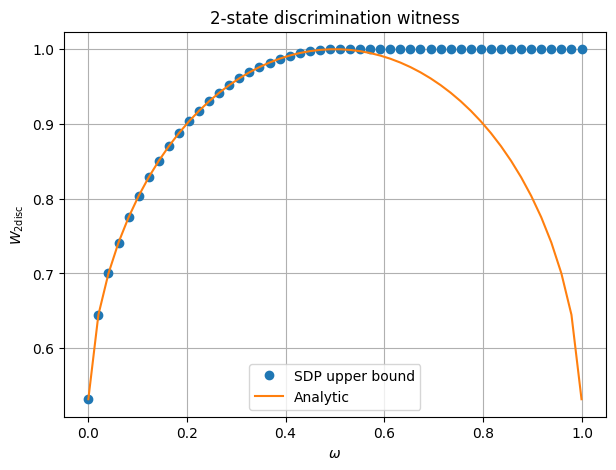

In [9]:
omegas = np.linspace(0.001, 0.999, 50)

sdp_values = []
analytic_values = []

for omega in omegas:
    res = solve_two_state_discrimination(omega)
    sdp_values.append(res["sdp_upper_bound"])
    analytic_values.append(res["analytic"])

plt.figure(figsize=(7, 5))
plt.plot(omegas, sdp_values, "o", label="SDP upper bound")
plt.plot(omegas, analytic_values, "-", label="Analytic")

plt.xlabel(r"$\omega$")
plt.ylabel(r"$W_{2\mathrm{disc}}$")
plt.title("2-state discrimination witness")
plt.legend()
plt.grid(True)
plt.show()